In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import sys, os
import re

%load_ext autoreload
%autoreload 2

sys.path.append('..')
from theory.theory import get_ld_z_covariance, get_ld_z_covariance_infty
from theory.utils import parse_config

%matplotlib inline

In [2]:
def identify_p_vals(res_path):
    # cause when we run code with the same parameters except different values of p,
    # it is overriden
    p_vals = []
    for f_path in os.listdir(res_path):
        res = re.search("^p([0-9]+)_S.npy$", f_path)
        if res is not None:
            p_vals.append(int(res.group(1)))
    p_vals = np.array(sorted(p_vals))
    return p_vals

ROOT_DIR = "/home/remizova/projects/sgf_dyn/results/"

GD_DIR = os.path.join(ROOT_DIR, "GD")
gd_res_folder = "lr1e-02_d100_n40_snr2e-01_nS5_Nmax1e+06_np50"
gd_res_path = os.path.join(GD_DIR, gd_res_folder)
gd_params = parse_config(os.path.join(gd_res_path, 'data/__parameters.txt'))
gd_p_vals = identify_p_vals(gd_res_path)

LD_DIR = os.path.join(ROOT_DIR, "LD")
ld_res_folder = "lr1e-02_eps1e-01_d100_n40_snr2e-01_nS5_nrun1_Nmax1e+06_np50"
ld_res_path = os.path.join(LD_DIR, ld_res_folder)
ld_params = parse_config(os.path.join(ld_res_path, 'data/__parameters.txt'))
ld_p_vals = identify_p_vals(ld_res_path)

for k, v in gd_params.items():
    if k in ['p', 'pID']:
        continue
    assert ld_params[k] == gd_params[k]

res_path = ld_res_path
params = ld_params

d = params['d']
n = params['n']
psi = d / n
lr = params['lr']
nS = params['nS']
epsilon = ld_params['epsilon']

p_vals = np.intersect1d(gd_p_vals, ld_p_vals, assume_unique=True)
alpha_vals = p_vals / n
assert len(p_vals) == len(gd_p_vals) and len(p_vals) == len(ld_p_vals)

In [3]:
def load_data(res_path, filenames):
    single = False
    if isinstance(filenames, (str, os.PathLike)):
        single = True
        filenames = [filenames]
    
    res = [
        np.load(os.path.join(res_path, name)) for name in filenames
    ]
    return res[0] if single else res


def data_equal(res_path_1, res_path_2, filenames):
    for name in filenames:
        data_1 = load_data(res_path_1, name)
        data_2 = load_data(res_path_2, name)
        if np.any(data_1 - data_2):
            raise ValueError('Different data used for trainings')
    print('all good!')


DATAGEN_NAMES = [
    f'data/{name}.npy' for name in ['X', 'betastar', 'y', 'beta0', 'plotlist']
]
PVAL_SET_NAMES = [f'p{p}_S.npy' for p in p_vals]

# # validation to make sure we ran algos on correct data and sets
# data_equal(gd_res_path, ld_res_path, DATAGEN_NAMES + PVAL_SET_NAMES)

X, beta_star, y, beta_0, plot_list = load_data(res_path, DATAGEN_NAMES)
n_time_points = plot_list.shape[0]

ALPHA_VALS_CHOSEN = [0.2, 0.5, 0.9, 1.1, 1.35]
P_VALS_CHOSEN = [int(alpha * n) for alpha in ALPHA_VALS_CHOSEN]

ALPHA_VALS_THEORY = np.linspace(0, 1.5, 100)
ALPHA_VALS_THEORY_UNDERP = np.linspace(0, 1, 101)[:-1]


T_VALS_SELECTED = np.logspace(0, 6, 7).astype(int)
T_INDICES_SELECTED = [1, 10, 19, 28, 37, 46, 55]
# T_VALS_SELECTED = []
# for t in np.logspace(0, 6, 7):
#     T_INDICES_SELECTED.append(int(np.searchsorted(plot_list, t)))

LD_GF_DIFF_LABEL = '$E^{{LD}}_{{test}} - E^{{GF}}_{{test}}$'


In [4]:
def compute_test(X, y, S, beta_S):
    """
    X: (n, d)
    y: (n,)
    S: (p,)
    beta_S: (...., p)
    """
    X_S = X[:, S]
    loss = np.mean((y - beta_S @ X_S.T) ** 2, axis=-1) / 2
    return loss


def compute_ld_gf_diff(X, y, p, idx_timepoints=None):
    p_S = load_data(ld_res_path, f'p{p}_S.npy')
    nS = p_S.shape[0]
    gd_p_DYN_betaS = load_data(gd_res_path, f'p{p}_DYN_betaS.npy')
    ld_p_DYN_betaS = load_data(ld_res_path, f'p{p}_DYN_betaS.npy')
    if idx_timepoints is not None:
        idx_timepoints = np.asarray(idx_timepoints)
        gd_p_DYN_betaS = gd_p_DYN_betaS[:, idx_timepoints, :]
        ld_p_DYN_betaS = ld_p_DYN_betaS[:, idx_timepoints, :]
        test_DYN = np.empty((nS, len(idx_timepoints)), dtype=float)
    else:
        test_DYN = np.empty((nS, n_time_points), dtype=float)
    for i_S in range(nS):
        S = p_S[i_S]
        gd_beta_S = gd_p_DYN_betaS[i_S] 
        ld_beta_S = ld_p_DYN_betaS[i_S]
        test_DYN[i_S] = compute_test(X, y, S, ld_beta_S) - compute_test(X, y, S, gd_beta_S)
    test_DYN = np.mean(test_DYN, axis=0)
    return test_DYN

## Figure 2

In [5]:
gf_ld_diff_tlim_empirical = []
for p in p_vals:
    gf_ld_diff_tlim_empirical.append(compute_ld_gf_diff(X, y, p, idx_timepoints=[-1]))
gf_ld_diff_tlim_empirical = np.array(gf_ld_diff_tlim_empirical)[:, 0]

gf_ld_diff_tlim_theory = epsilon * get_ld_z_covariance_infty(ALPHA_VALS_THEORY_UNDERP) / psi


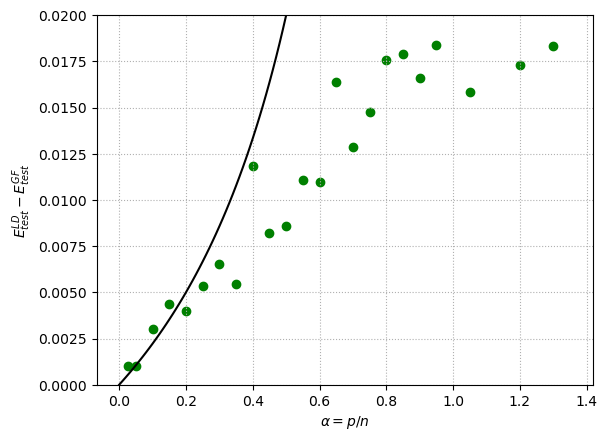

In [6]:
fig, ax = plt.subplots()
ax.plot(ALPHA_VALS_THEORY_UNDERP, gf_ld_diff_tlim_theory, c='black', label='Theory')
ax.scatter(alpha_vals, gf_ld_diff_tlim_empirical, c='green', label='Simulation')
ax.grid(ls=":")
ax.set_ylim(0, 0.02)
ax.set_xlabel('$\\alpha=p / n$')
ax.set_ylabel(LD_GF_DIFF_LABEL)
plt.show()


## Figure 3

In [7]:
gf_ld_diff_t_inter_empirical = []
for p in p_vals:
    gf_ld_diff_t_inter_empirical.append(compute_ld_gf_diff(X, y, p, idx_timepoints=T_INDICES_SELECTED))
gf_ld_diff_t_inter_empirical = np.stack(gf_ld_diff_t_inter_empirical, axis=-1)
gf_ld_diff_t_inter_theory = epsilon * get_ld_z_covariance(ALPHA_VALS_THEORY, T_VALS_SELECTED * lr).T / psi

/home/remizova/projects/sgf_dyn/notebooks/../theory/theory.py:214: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return quad(ld_integral_c, aminus, aplus, args=(arg_t, aminus, aplus))[0]
/home/remizova/projects/sgf_dyn/notebooks/../theory/theory.py:235: RuntimeWarning: divide by zero encountered in divide
  res += np.maximum(0, 1 - 1 / alphas) * ts / 2


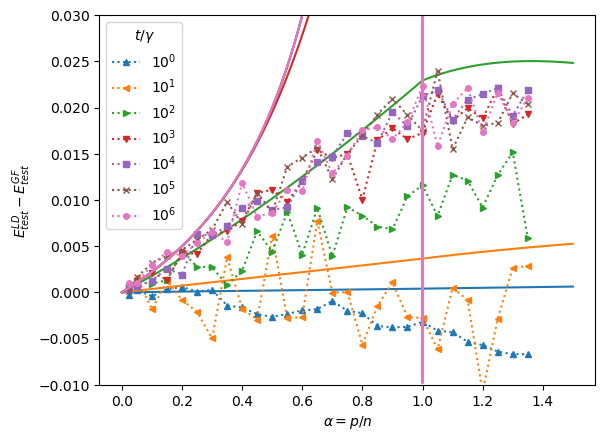

In [8]:
T_MARKERS = ["^", "<", ">", "v", "s", "x", "o"]
fig, ax = plt.subplots()
for i in range(len(T_INDICES_SELECTED)):
    line = ax.plot(alpha_vals, gf_ld_diff_t_inter_empirical[i], ls=':', marker=T_MARKERS[i],
                   markersize=4, label=f'$10^{int(np.log10(T_VALS_SELECTED[i]))}$')
    ax.plot(ALPHA_VALS_THEORY, gf_ld_diff_t_inter_theory[i],  c=line[0].get_color())
ax.set_ylim(-0.01, 0.03)
ax.legend(title="$t / \\gamma$")
ax.set_xlabel('$\\alpha=p / n$')
ax.set_ylabel(LD_GF_DIFF_LABEL)
plt.show()
    

## Figure 6

In [9]:
gf_ld_diff_tevol_empirical = []
for p in P_VALS_CHOSEN:
    gf_ld_diff_tevol_empirical.append(compute_ld_gf_diff(X, y, p))
gf_ld_diff_tevol_empirical = np.stack(gf_ld_diff_tevol_empirical)

gf_ld_diff_tevol_theory = epsilon * get_ld_z_covariance(ALPHA_VALS_CHOSEN, plot_list * lr) / psi
    

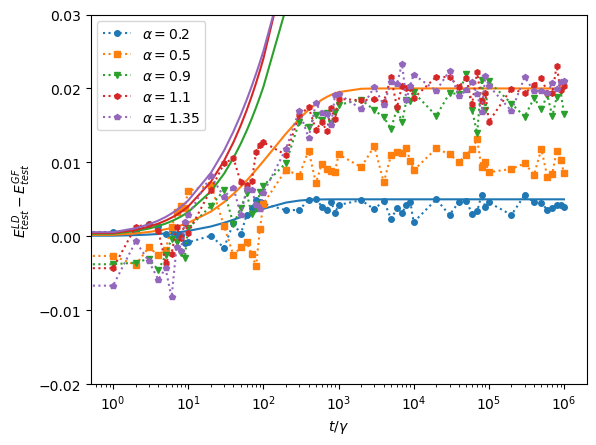

In [10]:
fig, ax = plt.subplots()

ALPHA_MARKERS = ["o", "s", "v", "h", "p"]
for i in range(len(ALPHA_VALS_CHOSEN)):
    line = ax.plot(plot_list, gf_ld_diff_tevol_empirical[i], ls=':', marker=ALPHA_MARKERS[i],
                   markersize=4, label=f'$\\alpha={ALPHA_VALS_CHOSEN[i]}$')
    ax.plot(plot_list, gf_ld_diff_tevol_theory[i], color=line[0].get_color())

ax.legend()
ax.set_xscale('log')
ax.set_xlabel("$t / \\gamma$")
ax.set_ylabel(LD_GF_DIFF_LABEL)
ax.set_ylim(-0.02, 0.03)
plt.show()